# **Pós-Graduação: Ciência de Dados e Inteligência Artificial.**
## **AED - Análise Estatística de Dados**
---
## **Gustavo Calin dos Santos 17.01190-6**


---

**Atividade 1 - Análise Estatística**

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1) Aquisição de dados:
## 2) Importação

In [67]:
# Importação de dados
df = pd.read_csv('Bank Marketing.csv')

# Exibe o início do dataset
df.head()

,Age,Job,Marital Status,Education,Credit,Balance (euros),Housing Loan,Personal Loan,Contact,Last Contact Day,Last Contact Month,Last Contact Duration,Campaign,Pdays,Previous,Poutcome,Subscription
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


## 3) Tratamento de dados

**a) Selecione as seguintes colunas para trabalhar: 'Age', 'Job', 'Marital Status', 'Education', 'Balance (euros)', 'Personal Loan',  'Previous', 'Subscription'.**

In [68]:
# Trabalhar somente com as colunas 'Age', 'Job', 'Marital Status', 'Education', 'Balance (euros)', 'Personal Loan',  'Previous', 'Subscription' e remover as outra colunas
df_bank = df[['Age', 'Job', 'Marital Status', 'Education', 'Balance (euros)', 'Personal Loan',  'Previous', 'Subscription']]
df_bank.head()

,Age,Job,Marital Status,Education,Balance (euros),Personal Loan,Previous,Subscription
0,58,management,married,tertiary,2143,no,0,1
1,44,technician,single,secondary,29,no,0,1
2,33,entrepreneur,married,secondary,2,yes,0,1
3,47,blue-collar,married,unknown,1506,no,0,1
4,33,unknown,single,unknown,1,no,0,1


In [69]:
# Dimensão do conjunto de dados
print('Dimensão do dataset', df_bank.shape)

Dimensão do dataset (45211, 8)


### Tratamento de Dados

**b) Renomeie as colunas, de forma a acessá-las mais facilmente;**



In [70]:
# Renomear as colunas manualmente para facilitar o acesso
df_bank.rename(columns={
    "Age": "idade",
    "Job": "trabalho",
    "Marital Status": "estado_civil",
    "Education": "grau_de_instrucao",
    "Balance (euros)": "saldo",
    "Personal Loan": "empréstimo",
    "Previous": "contato_feito_anteriormente",
    "Subscription": "subscreveu"
}, inplace=True)

<ipython-input-70-16a03863980e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bank.rename(columns={


In [71]:
print(df_bank.columns)

Index(['idade', 'trabalho', 'estado_civil', 'grau_de_instrucao', 'saldo',
       'empréstimo', 'contato_feito_anteriormente', 'subscreveu'],
      dtype='object')


**c) Verifique se há valores faltantes;**

In [72]:
# Verificar valores ausentes
df_bank.isnull().sum()

,0
idade,0
trabalho,0
estado_civil,0
grau_de_instrucao,0
saldo,0
empréstimo,0
contato_feito_anteriormente,0
subscreveu,0


**d) Exiba os valores possíveis de cada variável (value_counts);**

In [73]:
# Valores únicos
for col in df_bank.columns:
  print(col, ':', df_bank[col].unique())

idade : [58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81 18 89
 84 87 92 93 88]
trabalho : ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
estado_civil : ['married' 'single' 'divorced']
grau_de_instrucao : ['tertiary' 'secondary' 'unknown' 'primary']
saldo : [ 2143    29     2 ...  8205 14204 16353]
empréstimo : ['no' 'yes']
contato_feito_anteriormente : [  0   3   1   4   2  11  16   6   5  10  12   7  18   9  21   8  14  15
  26  37  13  25  20  27  17  23  38  29  24  51 275  22  19  30  58  28
  32  40  55  35  41]
subscreveu : [1 2]


**e) Identifique o tipo de cada variável: quantitativa (discreta, contínua) ou qualitativa (ordinal, nominal). Se for uma variável nominal, veja se é binária ou múltipla.**

In [74]:
# Tipos de variáveis
# idade Quantitativa Discretas
# trabalho Qualitativa Nominais
# estado_civil Qualitativa Nominais
# grau_de_instrucao Qualitativa Ordinais
# saldo Quantitativa Discretas
# empréstimo Qualitativa Ordinais
# contato_feito_anteriormente Quantitativa
# subscreveu Qualitativa Ordinais

**f) A variável ‘Education’ possui alguns indivíduos com nível educacional não identificado (‘unknown’). Registre a proporção de observações desse tipo (com duas casas decimais) e elimine as linhas com esse valor;**

In [75]:
# Proporção de observações com 'grau_de_instrucao' igual a 'unknown'
proporcao_unknown = (df_bank['grau_de_instrucao'] == 'unknown').mean()
print(f"Proporção de observações com grau de instrução desconhecido: {proporcao_unknown:.2f}")

# Eliminar linhas com 'grau_de_instrucao' igual a 'unknown'
df_bank = df_bank[df_bank['grau_de_instrucao'] != 'unknown']

Proporção de observações com grau de instrução desconhecido: 0.04


**g) Transforme as variáveis qualitativas binárias em 0-1 (pd.replace).**

In [76]:
df_bank['empréstimo'] = df_bank['empréstimo'].replace({'no': 0, 'yes': 1})

<ipython-input-76-40de4615aa9b>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bank['empréstimo'] = df_bank['empréstimo'].replace({'no': 0, 'yes': 1})
<ipython-input-76-40de4615aa9b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bank['empréstimo'] = df_bank['empréstimo'].replace({'no': 0, 'yes': 1})


**h) Arrume a coluna ‘Subscription’, alterando os valores de 1-2 para 0-1.**

In [77]:
df_bank['subscreveu'] = df_bank['subscreveu'].replace({1: 0, 2: 1})

<ipython-input-77-60ee25ee6b69>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bank['subscreveu'] = df_bank['subscreveu'].replace({1: 0, 2: 1})


In [78]:
df_bank.head()

,idade,trabalho,estado_civil,grau_de_instrucao,saldo,empréstimo,contato_feito_anteriormente,subscreveu
0,58,management,married,tertiary,2143,0,0,0
1,44,technician,single,secondary,29,0,0,0
2,33,entrepreneur,married,secondary,2,1,0,0
5,35,management,married,tertiary,231,0,0,0
6,28,management,single,tertiary,447,1,0,0


In [79]:
# Valores únicos
for col in df_bank.columns:
  print(col, ':', df_bank[col].unique())

idade : [58 44 33 35 28 42 43 41 29 53 57 51 60 56 32 25 40 39 52 46 36 49 59 37
 50 54 55 48 24 38 31 45 47 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 76 85 63 90 82 73 74 78 80 94 79 19 77 86 95 81 18 89
 84 87 88]
trabalho : ['management' 'technician' 'entrepreneur' 'retired' 'admin.' 'services'
 'blue-collar' 'self-employed' 'unemployed' 'housemaid' 'student'
 'unknown']
estado_civil : ['married' 'single' 'divorced']
grau_de_instrucao : ['tertiary' 'secondary' 'primary']
saldo : [ 2143    29     2 ...  8205 14204 16353]
empréstimo : [0 1]
contato_feito_anteriormente : [  0   3   1   4   2  11  16   6   5  10  12   7  18   9  21   8  14  15
  26  37  13  25  20  27  17  23  38  29  24  51 275  22  19  30  58  28
  32  40  55  35  41]
subscreveu : [0 1]


## 1) Análise unidimensional:

**a) Obtenha uma distribuição de frequência para a variável ‘job’. Encontre a frequência absoluta e relativa. Plote um gráfico de barras com a distribuição de frequência dessa variável.**

In [80]:
# Calcular a frequência absoluta
frequencia_absoluta = df_bank['trabalho'].value_counts().reset_index()
frequencia_absoluta.columns = ['Valor', 'Frequência Absoluta']

# Calcular a frequência relativa
frequencia_absoluta['Frequência Relativa'] = frequencia_absoluta['Frequência Absoluta'] / len(df)

# Percentual da frequência relativa
frequencia_absoluta['Frequência Percentual'] = frequencia_absoluta['Frequência Relativa'] * 100

# Criar a linha do total
total_row = pd.DataFrame({
    'Valor': ['Total'],
    'Frequência Absoluta': [frequencia_absoluta['Frequência Absoluta'].sum()],
    'Frequência Relativa': [frequencia_absoluta['Frequência Relativa'].sum()],
    'Frequência Percentual': [frequencia_absoluta['Frequência Percentual'].sum()]
})

# Concatenar a linha total ao DataFrame original
frequencia_absoluta = pd.concat([frequencia_absoluta, total_row], ignore_index=True)

# Exibir a tabela
print(frequencia_absoluta)

            Valor  Frequência Absoluta  Frequência Relativa  \
0     blue-collar                 9278             0.205216   
1      management                 9216             0.203844   
2      technician                 7355             0.162682   
3          admin.                 5000             0.110593   
4        services                 4004             0.088563   
5         retired                 2145             0.047444   
6   self-employed                 1540             0.034063   
7    entrepreneur                 1411             0.031209   
8      unemployed                 1274             0.028179   
9       housemaid                 1195             0.026432   
10        student                  775             0.017142   
11        unknown                  161             0.003561   
12          Total                43354             0.958926   

    Frequência Percentual  
0               20.521554  
1               20.384420  
2               16.268165  
3    

**b) Plote um histograma para a variável ‘Age’ com 8 bins (sns.histplot).**

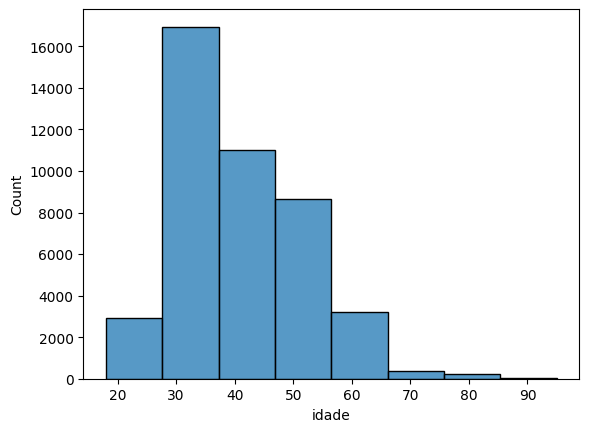

In [81]:
# Criando um histograma
sns.histplot(data=df_bank, x="idade", bins = 8)
plt.show()

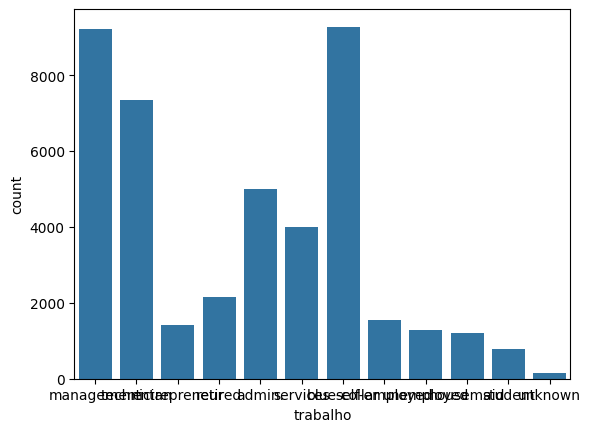

In [82]:
# gráfico de barras para a variável Job
sns.countplot(data=df_bank, x="trabalho")
plt.show()

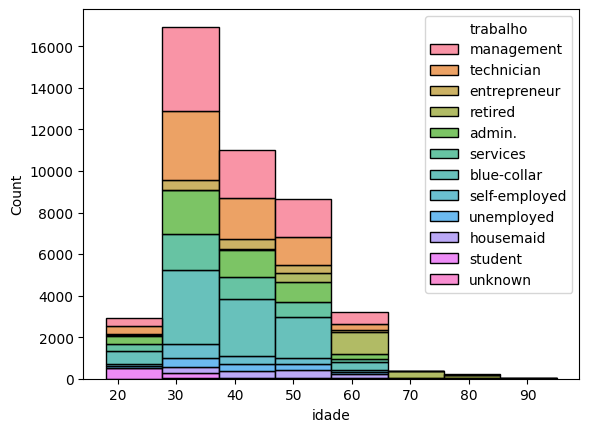

In [83]:
# histograma da variável age separado para cada categoria
sns.histplot(data=df_bank, x="idade", hue="trabalho", multiple="stack", bins = 8)
plt.show()

## 2) Estatística descritiva:

**a) Obtenha as principais estatísticas descritivas do dataset (describe).**

In [84]:
df_bank.describe()

,idade,saldo,empréstimo,contato_feito_anteriormente,subscreveu
count,43354.000000,43354.000000,43354.000000,43354.000000,43354.000000
mean,40.783111,1355.226715,0.164022,0.584260,0.116183
std,10.518987,3039.916830,0.370300,2.329661,0.320448
min,18.000000,-8019.000000,0.000000,0.000000,0.000000
25%,33.000000,71.000000,0.000000,0.000000,0.000000
50%,39.000000,443.000000,0.000000,0.000000,0.000000
75%,48.000000,1415.000000,0.000000,0.000000,0.000000
max,95.000000,102127.000000,1.000000,275.000000,1.000000


**b) Crie um conjunto de boxplots para a variável ‘Age’, um para cada uma das diferentes categorias de ‘Job’ (sns.boxplot).**

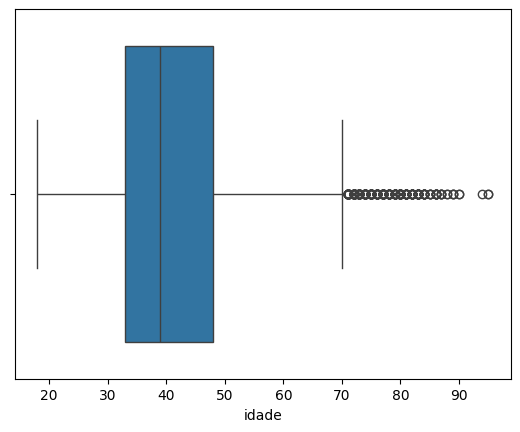

In [85]:
sns.boxplot(data=df_bank, x="idade")
plt.show()

## 3) Análise bidimensional:

**a) Obtenha a distribuição conjunta das variáveis ‘Education’ e ‘Marital’. Plote um gráfico com essa distribuição (sns.displot).**

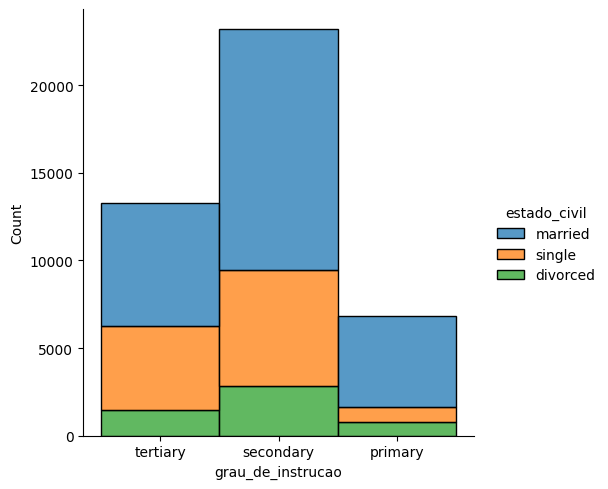

In [86]:
sns.displot(data=df_bank, x="grau_de_instrucao", hue="estado_civil", multiple="stack")

**b) Gere um  gráfico de dispersão para as variáveis ‘Age’ e ‘Balance’ (sns.scatterplot). Use cores para indicar se a pessoa aceitou o depósito a termo ou não.**

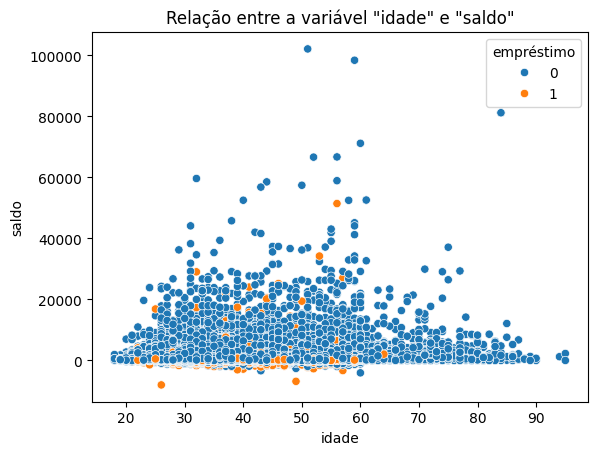

In [92]:
sns.scatterplot(data=df_bank, x="idade", y="saldo", hue="empréstimo").set(title='Relação entre a variável "idade" e "saldo"')
plt.show()

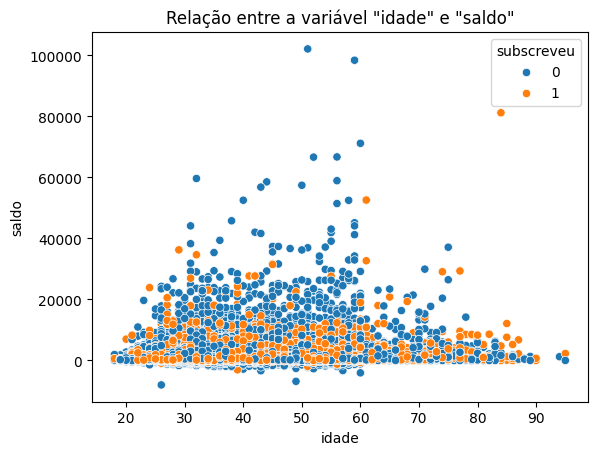

In [91]:
sns.scatterplot(data=df_bank, x="idade", y="saldo", hue="subscreveu").set(title='Relação entre a variável "idade" e "saldo"')
plt.show()

**c) Calcule a correlação entre as variáveis do dataframe e exiba os resultados em um mapa de calor (sns.heatmap).**

In [88]:
# Selecionar apenas as colunas numéricas
df_numerico = df_bank.select_dtypes(include=['number'])

# Criar a matriz de correlação
corr_matrix = df_numerico.corr()

print(corr_matrix)

                                idade     saldo  empréstimo  \
idade                        1.000000  0.097132   -0.010794   
saldo                        0.097132  1.000000   -0.084479   
empréstimo                  -0.010794 -0.084479    1.000000   
contato_feito_anteriormente  0.001175  0.016503   -0.011248   
subscreveu                   0.024187  0.051005   -0.068265   

                             contato_feito_anteriormente  subscreveu  
idade                                           0.001175    0.024187  
saldo                                           0.016503    0.051005  
empréstimo                                     -0.011248   -0.068265  
contato_feito_anteriormente                     1.000000    0.092295  
subscreveu                                      0.092295    1.000000  


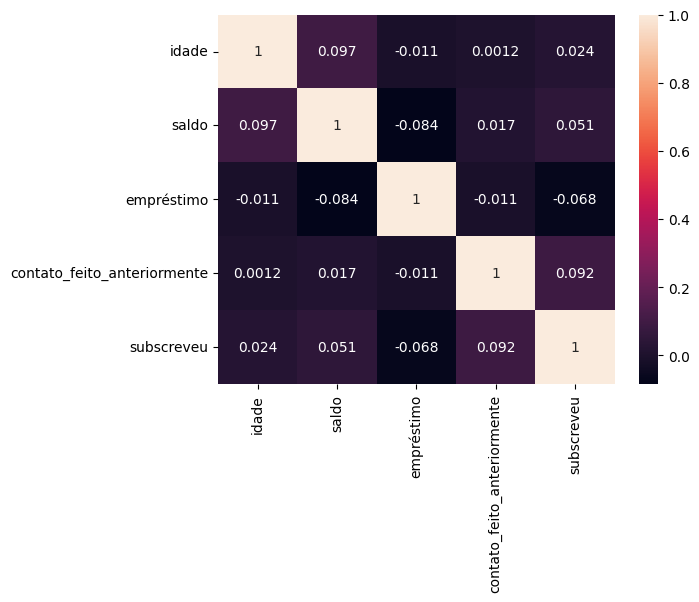

In [89]:
sns.heatmap(corr_matrix, annot=True)
plt.show()

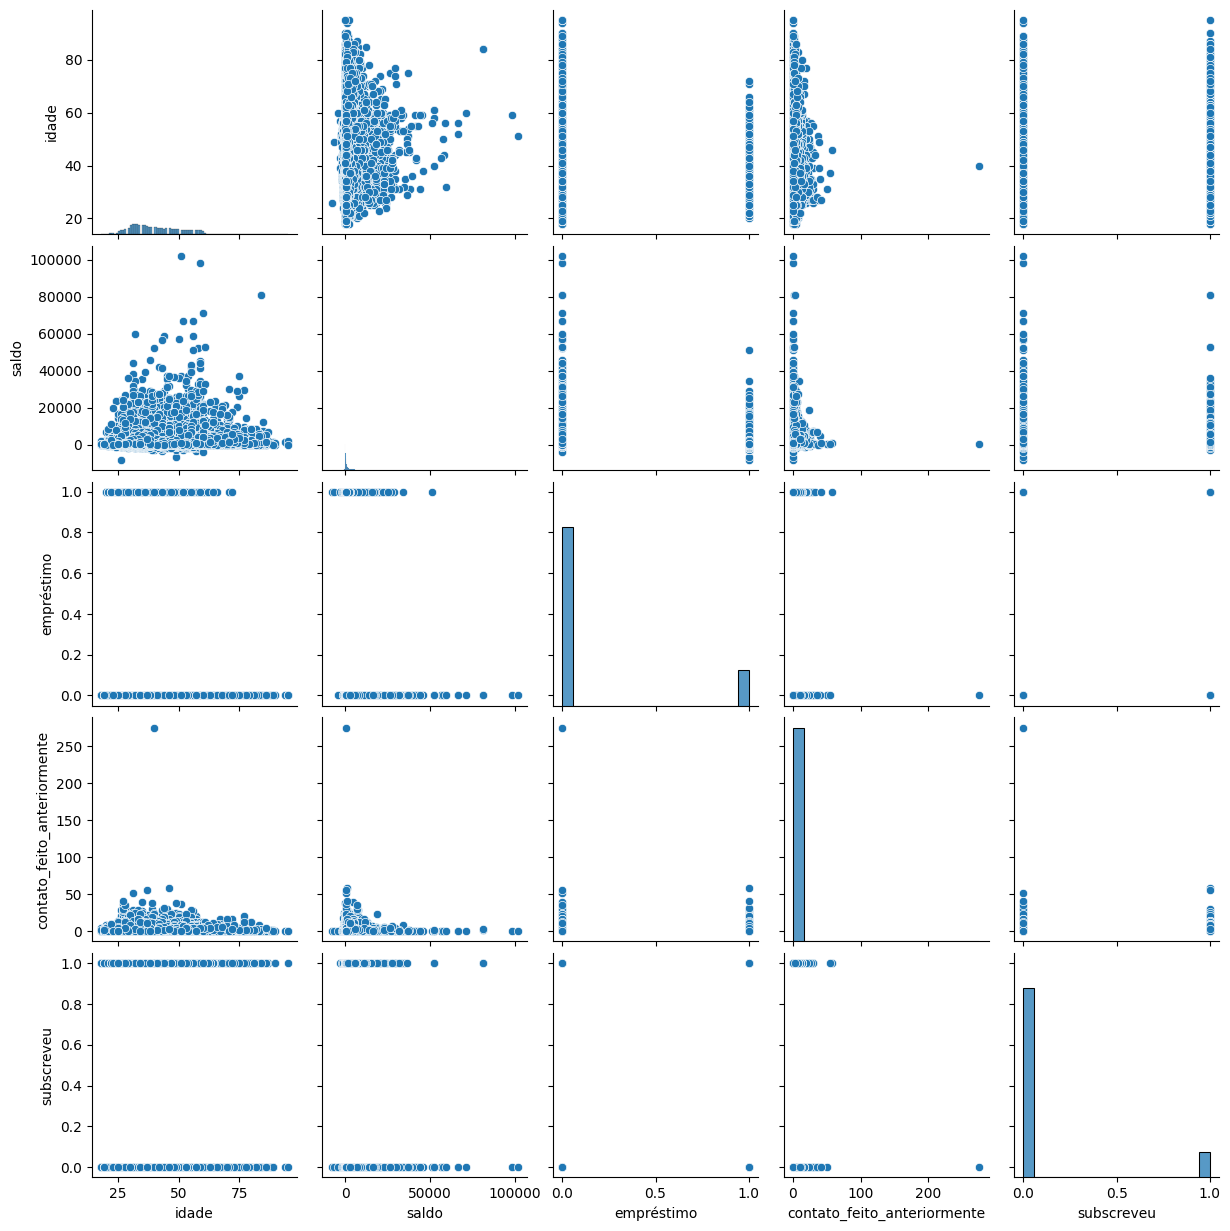

In [90]:
sns.pairplot(df_bank)
plt.show()